# 0. Helper Functions

This section defines functions for model training, evaluation, and visualization of results.

In [2]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import matplotlib.pyplot as plt
import matplotlib
import os, random
import numpy as np
import tensorflow as tf
import torch

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# matplotlib.rcParams.update({'font.size': 20})

# train SVM model using GridSearchCV
def train_svm(X_train, y_train):
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.05, 0.1, 0.2]
    }
    svr = SVR(kernel='rbf')
    grid_search = GridSearchCV(
        estimator=svr, param_grid=param_grid, cv=3,
        scoring='neg_mean_squared_error', verbose=2, n_jobs=-1
    )
    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()
    return grid_search.best_estimator_, end - start


# train Random Forest model using GridSearchCV
def train_rf(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [2, 3, 5, 10],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [5, 10, 20],
        'max_features': ['sqrt', 0.3]
    }

    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


# train HistGradientBoostingRegressor model using RandomizedSearchCV
def train_histgb(X_train, y_train):
    param_dist = {
        'learning_rate': uniform(0.01, 0.09),
        'max_iter': randint(50, 150),
        'max_depth': randint(2, 5),
        'min_samples_leaf': randint(20, 80),
        'l2_regularization': uniform(0.5, 2.5),
        'max_leaf_nodes': randint(5, 31)
    }
    model = HistGradientBoostingRegressor(early_stopping=True, random_state=42)
    grid_search = RandomizedSearchCV(
        estimator=model, param_distributions=param_dist, n_iter=20,
        scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=2, random_state=42
    )
    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()
    return grid_search.best_estimator_, end - start


# model evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, time=None):
    if time is not None:
        print(f"\n⏱️ Training Time: {time:.2f} seconds")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"📊 Train MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}")
    print(f"📊 Test  MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}\n")


# 1. Data Preprocessing

This notebook explores how combining different molecular representations affects the quality of molecular property prediction. We start by loading a dataset of 479 molecules, consisting of ChEMBL_ID identifiers and their _pIC50_ values (potency). SMILES strings are then fetched from the ChEMBL database using the molecule identifiers. Molecules are validated and converted to canonical form to ensure unambiguous SMILES representations.

In [3]:
import pandas as pd
import numpy as np

# load data
data = pd.read_csv('dopamine.csv', index_col=0)
data

,ChEMBL_ID,pIC50
0,CHEMBL303519,5.01
1,CHEMBL292943,7.30
2,CHEMBL61682,7.60
3,CHEMBL64487,6.44
4,CHEMBL64597,6.52
...,...,...
474,CHEMBL3805434,7.42
475,CHEMBL3805327,7.23
476,CHEMBL3805262,5.80
477,CHEMBL3805515,6.70


In [4]:
import requests
from rdkit import Chem
import xmltodict

# fetch SMILES strings from the ChEMBL database
smiles = []
for mol_id in data.ChEMBL_ID:
    response = requests.get(f'https://www.ebi.ac.uk/chembl/api/data/molecule/{mol_id}')
    smiles.append(Chem.CanonSmiles(xmltodict.parse(response.text)['molecule']['molecule_structures']['canonical_smiles']))
data['smiles'] = smiles

In [5]:
data.head()

,ChEMBL_ID,pIC50,smiles
0,CHEMBL303519,5.01,c1cnc(N2CCN(Cc3cccc4c3Cc3ccccc3-4)CC2)nc1
1,CHEMBL292943,7.30,COc1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1
2,CHEMBL61682,7.60,Fc1ccc(-c2cncc(CN3CCN(c4ccccc4F)CC3)c2)cc1
3,CHEMBL64487,6.44,COc1ccccc1-c1cccc(CN2CCN(c3ncccn3)CC2)c1
4,CHEMBL64597,6.52,c1cnc(N2CCN(Cc3cccc(-c4ccsc4)c3)CC2)nc1


In [6]:
# check that all SMILES strings were fetched
data.isna().sum()

ChEMBL_ID    0
pIC50        0
smiles       0
dtype: int64

All records were fetched successfully with no missing data. 
The data is split into subsets for training and testing in the ration 80:20.

In [7]:
from sklearn.model_selection import train_test_split
data_train, data_test = train_test_split(data, test_size=0.25, random_state=42)
len(data_train), len(data_test)

(359, 120)

The target feature _pIC50_ is then scaled to values between 0 and 1 on the training set and applied to the testing set.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_train['pIC50'] = scaler.fit_transform(np.array(data_train['pIC50']).reshape(-1,1))
data_test['pIC50']  = scaler.transform(np.array(data_test['pIC50']).reshape(-1,1))

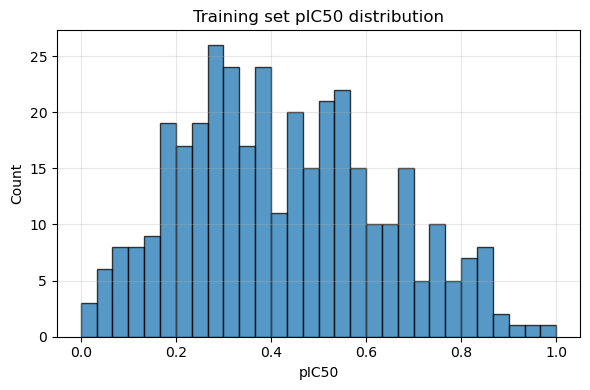

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data_train['pIC50'], bins=30, edgecolor='black', alpha=0.75)
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.title('Training set pIC50 distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Molecular Representations
The following sections generate different molecular representations: molecular descriptors, molecular fingerprints, and latent-space representations obtained using Mol2Vec and ChemBERTa models.

## 2.1. Molecular Descriptors

Molecular descriptors are computed using the Mordred calculator. The process starts from SMILES strings, from which 2D structures are generated using RDKit. Since Mordred also supports three-dimensional descriptors, molecules are converted to 3D structures. Each molecule is then temporarily saved in SDF format, which allows storing three-dimensional atomic coordinates and molecular metadata.

In [10]:
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors
import tempfile
import os

def generate_3d_conformer(mol):
    """
    Generate 3D conformer for a molecule.
    """
    mol = Chem.AddHs(mol)
    success = AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)
    if success == -1:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return None
    return mol

def smiles_to_sdf(df, smiles_col='smiles', id_col='ChEMBL_ID'):
    """
    Convert SMILES to SDF file with 3D conformers.
    """
    mols = []
    valid_indices = []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol is not None:
            mol_3d = generate_3d_conformer(mol)
            if mol_3d is not None:
                # Add properties to the molecule
                for col in df.columns:
                    if col != smiles_col:
                        mol_3d.SetProp(col, str(row[col]))
                mols.append(mol_3d)
                valid_indices.append(idx)
            else:
                print(f"Failed to generate 3D conformer for molecule {row[id_col]}")

    temp_sdf = tempfile.NamedTemporaryFile(suffix='.sdf', delete=False)
    writer = Chem.SDWriter(temp_sdf.name)

    for mol in mols:
        writer.write(mol)
    writer.close()

    return temp_sdf.name, valid_indices

def calculate_mordred_descriptors(sdf_file):
    """
    Calculate all Mordred descriptors including 3D.
    """
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [mol for mol in Chem.SDMolSupplier(sdf_file) if mol is not None]
    df_descriptors = calc.pandas(mols)
    return df_descriptors

def generate_molecular_descriptors(data, out_path='molecular_features.csv'):
    print("Converting SMILES to 3D structures and generating SDF file...")
    sdf_file, valid_indices = smiles_to_sdf(df=data)

    try:
        print("Calculating descriptors...")
        descriptors_df = calculate_mordred_descriptors(sdf_file)

        # Combine the descriptors with the original data
        valid_data = data.loc[valid_indices]
        final_dataset = pd.concat([valid_data.reset_index(drop=True), descriptors_df.reset_index(drop=True)], axis=1)

        # Save the complete dataset
        final_dataset.to_csv('molecular_features.csv', index=False)

        # Print summary statistics
        print("\nDataset Summary:")
        print(f"Total molecules processed: {len(final_dataset)}")
        print(f"Total features generated: {len(final_dataset.columns)}")

    finally:
        # Clean up temporary file
        os.remove(sdf_file)

    return final_dataset

In [11]:
data_train = generate_molecular_descriptors(data_train, out_path='molecular_features_train.csv')
data_test = generate_molecular_descriptors(data_test, out_path='molecular_features_test.csv')

Converting SMILES to 3D structures and generating SDF file...


[19:51:24] UFFTYPER: Unrecognized charge state for atom: 21


Calculating descriptors...


  0%|          | 1/359 [00:02<13:12,  2.21s/it]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

Calculating descriptors...


 24%|██▍       | 29/120 [00:03<00:04, 20.82it/s]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 120/120 [00:05<00:00, 23.20it/s]


c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)

Dataset Summary:
Total molecules processed: 120
Total features generated: 1829


Using Mordred, 1826 descriptors are computed per molecule, but a significant number are invalid. In practice, many descriptors can only be computed for specific molecules (e.g., organic ones), while others produce errors; often due to undefined operations such as division by zero. Such descriptors are removed from the dataset, along with those with very low variance (constant for most molecules). The variance threshold is set to $0.16$ (descriptors whose values are constant in ≥ 80% of samples).

In [12]:
from sklearn.feature_selection import VarianceThreshold

def prepare_features(train_df, test_df):
    string_columns_to_preserve = ['ChEMBL_ID', 'smiles', 'pIC50']

    preserved_train = train_df[string_columns_to_preserve]
    preserved_test  = test_df[string_columns_to_preserve]

    numeric_train = train_df.drop(columns=string_columns_to_preserve, errors='ignore').apply(pd.to_numeric, errors='coerce')
    numeric_test  = test_df.drop(columns=string_columns_to_preserve, errors='ignore').apply(pd.to_numeric, errors='coerce')
    print("Number of descriptors before cleaning:", numeric_train.shape[1])

    # which columns to keep — decided from TRAIN only
    keep_cols = numeric_train.dropna(axis=1).columns
    numeric_train = numeric_train[keep_cols]
    numeric_test  = numeric_test[keep_cols]
    print("Number of descriptors after removing NaN columns (train-based):", numeric_train.shape[1])

    # a test molecule can still fail on a column that every train molecule passed —
    # impute with the train median rather than dropping the column or leaving NaN
    train_medians = numeric_train.median()
    numeric_test = numeric_test.fillna(train_medians)

    # fit VarianceThreshold on train only, apply the SAME fitted selector to both
    selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
    selection.fit(numeric_train)
    selected_columns = numeric_train.columns[selection.get_support()]

    numeric_train = pd.DataFrame(selection.transform(numeric_train), columns=selected_columns)
    numeric_test  = pd.DataFrame(selection.transform(numeric_test), columns=selected_columns)
    print("Number of descriptors after cleaning:", numeric_train.shape[1] + len(string_columns_to_preserve))

    final_train = pd.concat([preserved_train.reset_index(drop=True), numeric_train.reset_index(drop=True)], axis=1)
    final_test  = pd.concat([preserved_test.reset_index(drop=True), numeric_test.reset_index(drop=True)], axis=1)

    return final_train, final_test

In [13]:
data_train, data_test = prepare_features(data_train, data_test)

Number of descriptors before cleaning: 1826
Number of descriptors after removing NaN columns (train-based): 1164
Number of descriptors after cleaning: 560


Although the number of features has been significantly reduced, 500+ descriptors still represents high dimensionality for machine learning. Further selection of the most informative descriptors is therefore needed.

The molecular descriptor selection process involves several steps:
1. Removal of autocorrelation descriptors, which are often redundant and less interpretable
2. Scaling descriptor values to the range [0, 1]
3. Feature importance estimation using a Random Forest algorithm
4. Removal of highly correlated features using Pearson's coefficient — all pairs of molecular descriptors with a Pearson coefficient above 0.9 are identified, and the descriptor with lower importance is removed
5. Recursive Feature Elimination with Cross-Validation (RFECV) — a supervised feature selection method that selects the optimal number of features based on the coefficient of determination

Feature selection is performed on the training sets.

In [14]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV

def efficient_feature_selection(X: pd.DataFrame,
                                y: pd.Series,
                                min_features: int = 20,
                                max_features: int = 30,
                                random_state: int = 42,
                                scale = True):
    """
    Efficient feature selection using a two-step approach:
    1. Remove autocorrelation descriptors
    2. Initial feature reduction using RandomForest importance
    3. Fine-tuning using RFECV with reduced feature set
    4. Post-processing to remove one of two highly correlated features.

    Args:
        X: Feature DataFrame
        y: Target Series
        min_features: Minimum number of features to select
        max_features: Maximum number of features for initial filtering
        random_state: Random seed for reproducibility

    Returns:
        Tuple of (selected features DataFrame, list of feature names)
    """
    orig_num = len(X.columns)

    # Step 0: Remove autocorrelation descriptors
    autocorr_keywords = ["ATSC", "AATS"]  # Keywords to identify autocorrelation descriptors
    autocorr_features = [
        col for col in X.columns if any(keyword in col for keyword in autocorr_keywords)
    ]
    X = X.drop(columns=autocorr_features)

    print(f"Removed {len(autocorr_features)} autocorrelation descriptors.")

    # Step 1: Scale the features
    if scale:
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X.to_numpy())
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    else:
        X_scaled = X.copy()

    # Step 2: Initial feature reduction using RandomForest importance
    pre_selector = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        n_jobs=-1,
        random_state=random_state
    )

    pre_selector.fit(X_scaled, y)

    # Get feature importance and select top features
    importances = pd.Series(pre_selector.feature_importances_, index=X.columns)
    importances_sorted = importances.sort_values(ascending=False)

    # Select top features (max_features or 2 * target_features, whichever is smaller)
    n_features_to_keep = min(max_features, len(importances_sorted))
    top_features = importances_sorted.head(n_features_to_keep).index.tolist()

    # Step 3: Filter to top features
    X_reduced = X_scaled[top_features]

    # Step 4: Post-processing - Remove highly correlated features
    # Calculate Pearson correlation
    corr_matrix = X_reduced.corr(method='pearson').abs()
    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)
    upper_corr_matrix = pd.DataFrame(corr_matrix.values * upper_triangle,
                                     columns=corr_matrix.columns,
                                     index=corr_matrix.index)

    # Identify pairs of highly correlated features
    high_corr_pairs = [(col1, col2)
                       for col1 in upper_corr_matrix.columns
                       for col2 in upper_corr_matrix.index
                       if upper_corr_matrix.loc[col2, col1] > 0.9]  # Threshold for correlation

    # Remove the feature with the smaller importance from each pair
    features_to_remove = set()
    for feat1, feat2 in high_corr_pairs:
        if feat1 in importances and feat2 in importances:
            # Compare importance and remove the less important feature
            if importances[feat1] > importances[feat2]:
                features_to_remove.add(feat2)
            else:
                features_to_remove.add(feat1)

    # Remove highly correlated features
    X_reduced = X_reduced.drop(columns=list(features_to_remove))
    top_features = [feat for feat in top_features if feat not in features_to_remove]
    print("Removed highly correlated features:", len(features_to_remove))

    # Step 5: RFECV on reduced feature set
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state
    )

    rfecv = RFECV(
        estimator=rf_model,
        step=1,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        min_features_to_select=min_features,
        verbose=0
    )

    rfecv.fit(X_reduced, y)

    # Get final selected features
    final_features = X_reduced.columns[rfecv.support_].tolist()

    # Calculate final feature importance
    final_importance = pd.Series(
        rfecv.estimator_.feature_importances_,
        index=final_features
    ).sort_values(ascending=False)

    print(f'Number of features reduced from {orig_num} to {len(final_features)}.')

    return X[final_features], final_features, final_importance

def plot_importance(selected_features, final_importance):
    # final_importance_scaled = (final_importance - min(final_importance)) / (max(final_importance) - min(final_importance))
    importances_rfe = dict(zip(selected_features, final_importance))
    plt.barh(selected_features, final_importance)
    plt.show()
    print(importances_rfe)

In [15]:
X_descriptors_train = data_train.drop(columns=['pIC50', 'ChEMBL_ID', 'smiles']).copy()
X_descriptors_test = data_test.drop(columns=['pIC50', 'ChEMBL_ID', 'smiles']).copy()

y_train = np.array(data_train['pIC50'])
y_test = np.array(data_test['pIC50'])

Removed 156 autocorrelation descriptors.
Removed highly correlated features: 6
Number of features reduced from 557 to 24.


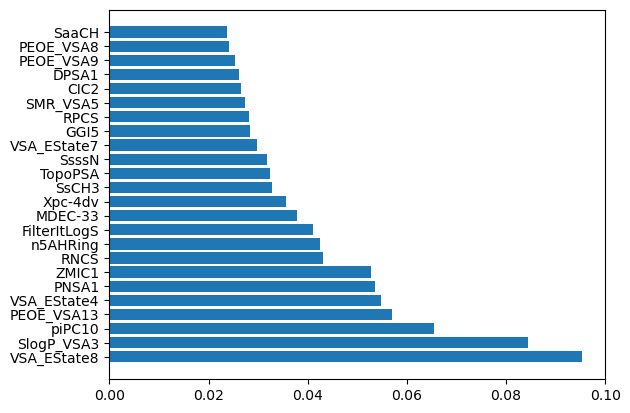

{'VSA_EState8': 0.09527173087306604, 'SlogP_VSA3': 0.08436993054183951, 'piPC10': 0.06546416763514855, 'PEOE_VSA13': 0.05705686917593948, 'VSA_EState4': 0.05482703372330696, 'PNSA1': 0.053590010068997045, 'ZMIC1': 0.05272803463712801, 'RNCS': 0.0431671030077141, 'n5AHRing': 0.042568901764894404, 'FilterItLogS': 0.041133539400074595, 'MDEC-33': 0.037783417655784725, 'Xpc-4dv': 0.03554402129681031, 'SsCH3': 0.03279465178105262, 'TopoPSA': 0.03235196256604563, 'SsssN': 0.031750769133941745, 'VSA_EState7': 0.02987813996989307, 'GGI5': 0.028268039164105876, 'RPCS': 0.02825235789320179, 'SMR_VSA5': 0.027274062770139922, 'CIC2': 0.02655484487499873, 'DPSA1': 0.026080216865789586, 'PEOE_VSA9': 0.02543648763682268, 'PEOE_VSA8': 0.024179819835945606, 'SaaCH': 0.023673887727359014}


In [16]:
X_selected_descriptors, selected_features_descriptors, final_importance_descriptors = efficient_feature_selection(
    X = X_descriptors_train,
    y = y_train,
    min_features = 20,
    max_features = 30
)

plot_importance(selected_features_descriptors, final_importance_descriptors)

156 autocorrelation descriptors and an additional 3 highly correlated features were removed. After RFECV selection, 23 descriptors remain.

In [17]:
# store selected features in X_train and X_test
X_descriptors_train = X_selected_descriptors.copy()
X_descriptors_test = X_descriptors_test[X_selected_descriptors.columns]

## 2.2. Molecular Fingerprints

Four types of molecular fingerprints (MACCS, Avalon, ECFP, and ErG) are generated using RDKit. Although initially implemented as specialized objects, all fingerprints are converted to binary vectors for simpler processing.

In [18]:
from rdkit.Chem import MACCSkeys
from rdkit.Chem.Pharm2D import Generate
from rdkit.Chem.Pharm2D import Gobbi_Pharm2D
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator

# Morgan
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)
data_train['morgan'] = data_train['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))
data_test['morgan'] = data_test['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))

# ErG (2D Pharmacophore / Scaffold hopping)
factory = Gobbi_Pharm2D.factory
def erg_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = Generate.Gen2DFingerprint(mol, factory)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['erg'] = data_train['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))
data_test['erg'] = data_test['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))

In [19]:
print("ECFP dimensionality: ", len(data_train['morgan'].tolist()[0]))
print("ErG dimensionality: ", len(data_train['erg'].tolist()[0]))

ECFP dimensionality:  512
ErG dimensionality:  39972


After conversion to binary vectors, ECFP fingerprints have dimension 512, and ErG fingerprints have dimension 39 972. Dimensionality reduction to 128 bits is applied to all molecular fingerprints.

Fingerprint dimensionality reduction is performed in two steps: removal of near-constant features followed by SVD decomposition. Removing near-constant features eliminates values that are identical for most molecules and therefore lack discriminative power. SVD (Singular Value Decomposition) is a linear method that decomposes the fingerprint matrix.

In [20]:
from sklearn.decomposition import TruncatedSVD

def reduce_fp(X_train, X_test, n_components=64):
    selector = VarianceThreshold(threshold=0.001)
    X_var_train = selector.fit_transform(X_train)
    X_var_test = selector.transform(X_test)
    print(f"After variance thresholding: {X_var_test.shape}")

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced_train = svd.fit_transform(X_var_train)
    X_reduced_test = svd.transform(X_var_test)

    print(f"After TruncatedSVD({n_components}): {X_reduced_train.shape}, "
          f"variance retained: {svd.explained_variance_ratio_.sum():.3f}")
    return X_reduced_train, X_reduced_test

X_ecfp_train, X_ecfp_test = reduce_fp(
    np.array(data_train['morgan'].tolist()), np.array(data_test['morgan'].tolist()), n_components=64)
X_erg_train, X_erg_test = reduce_fp(
    np.array(data_train['erg'].tolist()), np.array(data_test['erg'].tolist()), n_components=64)

After variance thresholding: (120, 507)
After TruncatedSVD(64): (359, 64), variance retained: 0.830
After variance thresholding: (120, 7947)
After TruncatedSVD(64): (359, 64), variance retained: 0.858


## 2.3. Mol2Vec

A pre-trained Mol2Vec model is used to generate the first type of latent molecular representations. Before using it, SMILES strings are converted to 2D structures using RDKit. The resulting molecules then serve as input to the Mol2Vec model, which transforms SMILES strings into latent representations.

In [21]:
from tqdm import tqdm

# because of version incompatibility
def sentences2vec(sentences, model, unseen='UNK'):
    """
    Convert a list of sentences (molecular substructure tokens) into vector representations
    using a gensim Word2Vec model (Gensim 4.x compatible).

    Parameters:
    - sentences: list of lists of substructure tokens (e.g., [['[C@@H]', '[CH3]'], ...])
    - model: gensim Word2Vec model (must be trained or preloaded)
    - unseen: token to use for unseen words (default 'UNK')

    Returns:
    - list of numpy arrays (each array = vector for one molecule)
    """
    vectors = []
    for sentence in tqdm(sentences, desc="Embedding molecules"):
        vecs = []
        for word in sentence:
            if word in model.wv:
                vecs.append(model.wv[word])
            elif unseen in model.wv:
                vecs.append(model.wv[unseen])
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            # In case no known words in sentence, use zero vector
            vectors.append(np.zeros(model.vector_size))
    return vectors


In [22]:
import gensim
from mol2vec.features import mol2alt_sentence
# from tqdm import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Load model
model = gensim.models.Word2Vec.load("models/model_300dim.pkl")
sentences_train = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_train['smiles'].tolist()]
sentences_test = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_test['smiles'].tolist()]

# Convert to vectors
vectors_train = sentences2vec(sentences_train, model)
vectors_test = sentences2vec(sentences_test, model)
data_train['mol2vec'] = vectors_train
data_test['mol2vec'] = vectors_test

Embedding molecules: 100%|██████████| 120/120 [00:00<00:00, 10245.21it/s]


In [23]:
print("Mol2Vec embeddings dimensionality: ", len(data_train['mol2vec'].tolist()[0]))

Mol2Vec embeddings dimensionality:  300


To facilitate later training and comparison of predictive models, dimensionality was reduced from 300 to 128 using an autoencoder.

The autoencoder consists of an input layer, a single dense layer serving as the encoder, and another dense layer serving as the decoder. The model was trained for 50 epochs on the training set using batches of 32 molecules.

In [24]:
from tensorflow.keras import layers, models
import tensorflow as tf

def reduce_embedding_dim(X_train, X_test, encoding_dim=128, seed=42):
    tf.random.set_seed(seed)

    input_dim = X_train.shape[1]

    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(input_layer)
    decoded = layers.Dense(input_dim, activation='linear',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(encoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True)

    X_reduced_train = encoder.predict(X_train)
    X_reduced_test = encoder.predict(X_test)

    return X_reduced_train, X_reduced_test

Conducting a test to see how much of a drop in performace reduction to 64 dimensions causes in comparision to reduction to 128 dimensions.

In [25]:
def reconstruction_quality(X_train, encoding_dim, seed=42):
    tf.random.set_seed(seed)
    input_dim = X_train.shape[1]
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(input_layer)
    decoded = layers.Dense(input_dim, activation='linear',
                            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(encoded)
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True, verbose=0)

    final_mse = history.history['loss'][-1]
    pseudo_r2 = 1 - final_mse / np.var(X_train)
    print(f"encoding_dim={encoding_dim}: final MSE={final_mse:.4f}, pseudo-R²={pseudo_r2:.3f}")
    return pseudo_r2

X_mol2vec_train_arr = np.array([emb for emb in data_train['mol2vec']])
reconstruction_quality(X_mol2vec_train_arr, 64)
reconstruction_quality(X_mol2vec_train_arr, 128)




encoding_dim=64: final MSE=0.0003, pseudo-R²=0.978
encoding_dim=128: final MSE=0.0002, pseudo-R²=0.986


0.9855892464125118

In [26]:
X_mol2vec_train, X_mol2vec_test = reduce_embedding_dim(
    np.array([emb for emb in data_train['mol2vec']]),
    np.array([emb for emb in data_test['mol2vec']]),
    encoding_dim=64)

print("\nMol2Vec embeddings dimensionality after reduction: ", X_mol2vec_train.shape[1])

Epoch 1/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0109
Epoch 2/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0050
Epoch 3/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0022
Epoch 4/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0012
Epoch 5/50
12/12 [==============================] - 0s 1ms/step - loss: 9.7883e-04
Epoch 6/50
12/12 [==============================] - 0s 1ms/step - loss: 9.1138e-04
Epoch 7/50
12/12 [==============================] - 0s 1ms/step - loss: 8.7854e-04
Epoch 8/50
12/12 [==============================] - 0s 1ms/step - loss: 8.5040e-04
Epoch 9/50
12/12 [==============================] - 0s 1ms/step - loss: 8.2637e-04
Epoch 10/50
12/12 [==============================] - 0s 1ms/step - loss: 7.9784e-04
Epoch 11/50
12/12 [==============================] - 0s 1ms/step - loss: 7.6772e-04
Epoch 12/50
12/12 [==============================] - 0s 1ms/step - loss: 7.3606e-04
Epoch 13/50
12/12

## 2.4. ChemBERTa

Generating the second type of latent representations using ChemBERTa is a somewhat more complex and time-consuming process. This model is also pre-trained on a large number of molecules, but here it is additionally fine-tuned on the potency prediction training set. Training is carried out for 20 epochs using 3-fold cross-validation, with the Adam optimizer at a learning rate of 10⁻⁵. After fine-tuning, the model is used to generate latent representations for molecules in the test set.

In [27]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch.nn as nn
import torch
from torch.utils.data import Dataset

model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(smiles):
    return tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')

class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets):
        self.inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors='pt')
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return (
            self.inputs['input_ids'][idx],
            self.inputs['attention_mask'][idx],
            self.targets[idx]
        )
    
class ChemBERTaRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.chemberta.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.chemberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(pooled_output), pooled_output  # return both prediction and embedding


def train_model(model, dataloader, optimizer, device):
    model.train()
    for input_ids, attn_mask, targets in dataloader:
        input_ids, attn_mask, targets = input_ids.to(device), attn_mask.to(device), targets.to(device)
        preds, _ = model(input_ids, attn_mask)
        loss = nn.MSELoss()(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [28]:
from sklearn.model_selection import KFold
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

smiles_list = data_train['smiles'].tolist()
targets = data_train['pIC50'].tolist()

inputs = tokenize(smiles_list)
X = inputs['input_ids']
attention = inputs['attention_mask']
y = torch.tensor(targets).float().unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_EPOCHS = 20
N_SPLITS = 3
SEED = 42
torch.manual_seed(SEED)

# --- Phase 1: K-fold CV, purely to get an honest validation estimate of the fine-tuning recipe.
# Fresh model per fold is fine here -- these are disposable, only the val MSE matters.
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)  # one fixed split, not re-shuffled per epoch
fold_mse_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(smiles_list)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    train_smiles = [smiles_list[i] for i in train_idx]
    val_smiles   = [smiles_list[i] for i in val_idx]
    train_targets = y[train_idx]
    val_targets   = y[val_idx]

    train_dataset = SMILESDataset(train_smiles, train_targets)
    val_dataset   = SMILESDataset(val_smiles, val_targets)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                               generator=torch.Generator().manual_seed(SEED))
    val_loader   = DataLoader(val_dataset, batch_size=32)

    fold_model = ChemBERTaRegressor(model_name).to(device)
    optimizer  = Adam(fold_model.parameters(), lr=2e-5)

    # this fold's model now genuinely trains for all N_EPOCHS, not just one
    for epoch in range(N_EPOCHS):
        train_model(fold_model, train_loader, optimizer, device)

    fold_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for input_ids, attn_mask, val_y in val_loader:
            input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
            preds, _ = fold_model(input_ids, attn_mask)
            all_preds.append(preds.cpu())
            all_targets.append(val_y)

    preds_cat = torch.cat(all_preds).squeeze()
    targets_cat = torch.cat(all_targets).squeeze()
    mse = nn.MSELoss()(preds_cat, targets_cat)
    fold_mse_list.append(mse.item())
    print(f"Fold {fold+1} MSE: {mse.item():.4f}")

print(f"\n✅ CV MSE (mean across {N_SPLITS} folds, {N_EPOCHS}-epoch fine-tune each): {sum(fold_mse_list)/N_SPLITS:.4f}")

# --- Phase 2: fine-tune ONE final model on the FULL training set for N_EPOCHS.
# This is the model actually used downstream for embedding extraction.
full_dataset = SMILESDataset(smiles_list, y)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))

model = ChemBERTaRegressor(model_name).to(device)
optimizer = Adam(model.parameters(), lr=2e-5)

for epoch in range(N_EPOCHS):
    train_model(model, full_loader, optimizer, device)
    print(f"Final fine-tune epoch {epoch+1}/{N_EPOCHS} done")


--- Fold 1/3 ---


C:\Users\afs\AppData\Local\Temp\ipykernel_27096\1520311805.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.targets = torch.tensor(targets).float().unsqueeze(1)
c:\Users\afs\anaconda3\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
c:\Users\afs\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same 

Fold 1 MSE: 0.0475

--- Fold 2/3 ---


C:\Users\afs\AppData\Local\Temp\ipykernel_27096\1520311805.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.targets = torch.tensor(targets).float().unsqueeze(1)


Fold 2 MSE: 0.0459

--- Fold 3/3 ---
Fold 3 MSE: 0.0470

✅ CV MSE (mean across 3 folds, 20-epoch fine-tune each): 0.0468


c:\Users\afs\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([7, 1, 1])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Final fine-tune epoch 1/20 done
Final fine-tune epoch 2/20 done
Final fine-tune epoch 3/20 done
Final fine-tune epoch 4/20 done
Final fine-tune epoch 5/20 done
Final fine-tune epoch 6/20 done
Final fine-tune epoch 7/20 done
Final fine-tune epoch 8/20 done
Final fine-tune epoch 9/20 done
Final fine-tune epoch 10/20 done
Final fine-tune epoch 11/20 done
Final fine-tune epoch 12/20 done
Final fine-tune epoch 13/20 done
Final fine-tune epoch 14/20 done
Final fine-tune epoch 15/20 done
Final fine-tune epoch 16/20 done
Final fine-tune epoch 17/20 done
Final fine-tune epoch 18/20 done
Final fine-tune epoch 19/20 done
Final fine-tune epoch 20/20 done


In [29]:
model.eval()
with torch.no_grad():
    y_chemberta_train, embeddings = model(X.to(device), attention.to(device))
embeddings = embeddings.cpu().numpy()
data_train['embedding'] = [np.array(emb) for emb in embeddings]


inputs_test = tokenize(data_test['smiles'].tolist())
X_test = inputs_test['input_ids']
attention_test = inputs_test['attention_mask']
y_test = torch.tensor(data_test['pIC50'].tolist()).float().unsqueeze(1)

with torch.no_grad():
    y_chemberta_test, embeddings_test = model(X_test.to(device), attention_test.to(device))
embeddings_test = embeddings_test.cpu().numpy()
data_test['embedding'] = [np.array(emb) for emb in embeddings_test]

In [30]:
print("ChemBERTa embeddings dimensionality: ", len(data_train['embedding'].tolist()[0]))

ChemBERTa embeddings dimensionality:  768


The dimensionality of the latent representation is reduced in the same way as for Mol2Vec, using an autoencoder.

In [31]:
X_chemberta_train_arr = np.array([emb for emb in data_train['embedding']])
reconstruction_quality(X_chemberta_train_arr, 64)
reconstruction_quality(X_chemberta_train_arr, 128)

encoding_dim=64: final MSE=0.0209, pseudo-R²=0.979
encoding_dim=128: final MSE=0.0158, pseudo-R²=0.984


0.9842543439732526

In [32]:
X_chemberta_train, X_chemberta_test = reduce_embedding_dim(
    np.array([emb for emb in data_train['embedding']]),
    np.array([emb for emb in data_test['embedding']]),
    encoding_dim=64)

Epoch 1/50
12/12 [==============================] - 0s 2ms/step - loss: 0.7864
Epoch 2/50
12/12 [==============================] - 0s 1ms/step - loss: 0.2551
Epoch 3/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0949
Epoch 4/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0618
Epoch 5/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0535
Epoch 6/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0515
Epoch 7/50
12/12 [==============================] - 0s 2ms/step - loss: 0.0506
Epoch 8/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0501
Epoch 9/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0497
Epoch 10/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0496
Epoch 11/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0493
Epoch 12/50
12/12 [==============================] - 0s 1ms/step - loss: 0.0486
Epoch 13/50
12/12 [==============================

The following functions handle saving and loading the generated molecular representations, so that time-consuming procedures do not need to be repeated from scratch.

In [33]:
import pickle, os

os.makedirs("./data", exist_ok=True)
RECOMPUTE = True  # set to False only after you've verified the fixed pipeline end-to-end once

train_vars = {
    "X_descriptors_train": X_descriptors_train,
    "X_ecfp_train": X_ecfp_train,
    "X_erg_train": X_erg_train,
    "X_mol2vec_train": X_mol2vec_train,
    "X_chemberta_train": X_chemberta_train,
    "data_train": data_train,
}
test_vars = {
    "X_descriptors_test": X_descriptors_test,
    "X_ecfp_test": X_ecfp_test,
    "X_erg_test": X_erg_test,
    "X_mol2vec_test": X_mol2vec_test,
    "X_chemberta_test": X_chemberta_test,
    "data_test": data_test,
}

if RECOMPUTE:
    for name, val in {**train_vars, **test_vars}.items():
        with open(f"./data/{name}_v2.pkl", "wb") as f:
            pickle.dump(val, f)
else:
    for name in {**train_vars, **test_vars}:
        with open(f"./data/{name}_v2.pkl", "rb") as f:
            globals()[name] = pickle.load(f)

# 3. Comparison of Predictive Models

Three predictive models are used for molecular property prediction: Random Forest (RF), Support Vector Machine (SVM), and HistGradientBoostingRegressor (HGBR).

Each model is trained separately on four different types of molecular representations: molecular descriptors, a combined set of molecular fingerprints, Mol2Vec latent representations, and ChemBERTa latent representations. The latter two are treated separately due to their different nature and the NLP techniques applied, enabling comparison of their performance.

Models are also trained on combined molecular representations formed by concatenating different feature sets into a single vector. The results will indicate whether combining different molecular representations improves predictive performance.

To further test the combined-representation approach, models trained on each of the four representation types are assembled into a stacking ensemble. Ridge regression (a form of linear regression with L2 regularization) is used as the meta-model. Ridge regression is preferred here because it is robust to correlated inputs, less prone to overfitting, computationally efficient, and has proven effective in ensemble learning.

In [34]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

train_scaffolds = data_train['smiles'].apply(generate_scaffold)
scaffold_to_id = {s: i for i, s in enumerate(train_scaffolds.unique())}
groups_train = train_scaffolds.map(scaffold_to_id).values

Before training, all input molecular features are standardized to the same scale.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler_desc = StandardScaler()
X_descriptors_train = scaler_desc.fit_transform(X_descriptors_train.values)
X_descriptors_test  = scaler_desc.transform(X_descriptors_test.values)

scaler_ecfp = StandardScaler()
X_ecfp_train = scaler_ecfp.fit_transform(X_ecfp_train)
X_ecfp_test  = scaler_ecfp.transform(X_ecfp_test)

scaler_erg = StandardScaler()
X_erg_train = scaler_erg.fit_transform(X_erg_train)
X_erg_test  = scaler_erg.transform(X_erg_test)

scaler_mol2vec = StandardScaler()
X_mol2vec_train = scaler_mol2vec.fit_transform(X_mol2vec_train)
X_mol2vec_test  = scaler_mol2vec.transform(X_mol2vec_test)

scaler_chemberta = StandardScaler()
X_chemberta_train = scaler_chemberta.fit_transform(X_chemberta_train)
X_chemberta_test  = scaler_chemberta.transform(X_chemberta_test)

RF and SVM models are trained with 3-fold cross-validation on the training set. Hyperparameter optimization for RF and SVM is performed separately for each model using Grid Search.

HGBR hyperparameter optimization is performed using Randomized Search.

Predictive model performance is evaluated using three metrics: Mean Squared Error (MSE), Mean Absolute Error (MAE), and the coefficient of determination R².

In [36]:
X_combined_train = np.hstack([
    X_descriptors_train,
    X_ecfp_train,
    X_erg_train,
    X_mol2vec_train,
    X_chemberta_train
])

y_train = np.array(data_train['pIC50'])

X_combined_test = np.hstack([
    X_descriptors_test,
    X_ecfp_test,
    X_erg_test,
    X_mol2vec_test,
    X_chemberta_test
])

y_test = np.array(data_test['pIC50'])

print("Combined dimensionality: ", X_combined_train.shape[1])

Combined dimensionality:  280


## 3.1. RF

In [38]:
# molecular descriptors
print('Molecular descriptors')
rf_descriptors, rf_descriptors_time = train_rf(X_descriptors_train, y_train)
evaluate_model(rf_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, rf_descriptors_time)

# molecular fingerprints - ECFP
print('Molecular fingerprints - ECFP')
rf_ecfp, rf_ecfp_time = train_rf(X_ecfp_train, y_train)
evaluate_model(rf_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, rf_ecfp_time)

# molecular fingerprints - ErG
print('Molecular fingerprints - ErG')
rf_erg, rf_erg_time = train_rf(X_erg_train, y_train)
evaluate_model(rf_erg, X_erg_train, y_train, X_erg_test, y_test, rf_erg_time)

# molecular embeddings: mol2vec
print('Molecular embeddings - Mol2Vec')
rf_mol2vec, rf_mol2vec_time = train_rf(X_mol2vec_train, y_train)
evaluate_model(rf_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, rf_mol2vec_time)

# molecular embeddings: chemberta
print('Molecular embeddings - Chemberta')
rf_chemberta, rf_chemberta_time = train_rf(X_chemberta_train, y_train)
evaluate_model(rf_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, rf_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 8.57 seconds
📊 Train MSE: 0.0113, MAE: 0.0819, R2: 0.7418
📊 Test  MSE: 0.0328, MAE: 0.1435, R2: 0.3355

Molecular fingerprints - ECFP
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 7.41 seconds
📊 Train MSE: 0.0085, MAE: 0.0707, R2: 0.8060
📊 Test  MSE: 0.0314, MAE: 0.1392, R2: 0.3648

Molecular fingerprints - ErG
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 7.23 seconds
📊 Train MSE: 0.0081, MAE: 0.0689, R2: 0.8158
📊 Test  MSE: 0.0273, MAE: 0.1252, R2: 0.4467

Molecular embeddings - Mol2Vec
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 6.50 seconds
📊 Train MSE: 0.0109, MAE: 0.0815, R2: 0.7504
📊 Test  MSE: 0.0359, MAE: 0.1530, R2: 0.2742

Molecular embeddings - Chemberta
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 6.44 seconds
📊 Train MSE: 0.0

In [40]:
# concatenated combination
print('Combined molecular representations')
rf_combined, rf_combined_time = train_rf(X_combined_train, y_train)
evaluate_model(rf_combined, X_combined_train, y_train, X_combined_test, y_test, rf_combined_time)

Combined molecular representations
Fitting 3 folds for each of 144 candidates, totalling 432 fits

⏱️ Training Time: 11.29 seconds
📊 Train MSE: 0.0064, MAE: 0.0605, R2: 0.8530
📊 Test  MSE: 0.0315, MAE: 0.1402, R2: 0.3636



In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge

# out-of-fold predictions for meta-model training only — avoids fitting Ridge on optimistic in-sample predictions
oof_descriptors = cross_val_predict(RandomForestRegressor(**rf_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(RandomForestRegressor(**rf_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(RandomForestRegressor(**rf_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(RandomForestRegressor(**rf_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(RandomForestRegressor(**rf_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

meta_test = np.vstack((
    rf_descriptors.predict(X_descriptors_test),
    rf_ecfp.predict(X_ecfp_test),
    rf_erg.predict(X_erg_test),
    rf_mol2vec.predict(X_mol2vec_test),
    rf_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Stacking ensemble
Training MSE: 0.0209, MAE: 0.1112, R2: 0.5232
Test MSE: 0.0281, MAE: 0.1284, R2: 0.4305


## 3.2. SVM

In [42]:
# molecular descriptors
print('Molecular descriptors')
svm_descriptors, svm_descriptors_time = train_svm(X_descriptors_train, y_train)
evaluate_model(svm_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, svm_descriptors_time)

# molecular fingerprints - ECFP
print('Molecular fingerprints  ECFP')
svm_ecfp, svm_ecfp_time = train_svm(X_ecfp_train, y_train)
evaluate_model(svm_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, svm_ecfp_time)

# molecular fingerprints - ErG
print('Molecular fingerprints - ErG')
svm_erg, svm_erg_time = train_svm(X_erg_train, y_train)
evaluate_model(svm_erg, X_erg_train, y_train, X_erg_test, y_test, svm_erg_time)

# mol2vec
print('Mol2Vec')
svm_mol2vec, svm_mol2vec_time = train_svm(X_mol2vec_train, y_train)
evaluate_model(svm_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, svm_mol2vec_time)

# chemberta
print('Chemberta')
svm_chemberta, svm_chemberta_time = train_svm(X_chemberta_train, y_train)
evaluate_model(svm_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, svm_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.18 seconds
📊 Train MSE: 0.0069, MAE: 0.0748, R2: 0.8412
📊 Test  MSE: 0.0302, MAE: 0.1407, R2: 0.3881

Molecular fingerprints  ECFP
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.19 seconds
📊 Train MSE: 0.0030, MAE: 0.0462, R2: 0.9318
📊 Test  MSE: 0.0279, MAE: 0.1330, R2: 0.4351

Molecular fingerprints - ErG
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.21 seconds
📊 Train MSE: 0.0052, MAE: 0.0568, R2: 0.8804
📊 Test  MSE: 0.0268, MAE: 0.1240, R2: 0.4573

Mol2Vec
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.21 seconds
📊 Train MSE: 0.0037, MAE: 0.0502, R2: 0.9165
📊 Test  MSE: 0.0312, MAE: 0.1438, R2: 0.3693

Chemberta
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.21 seconds
📊 Train MSE: 0.0170, MAE: 0.1044, R2: 0.6124
📊 Test  MSE: 0.0326, MA

In [ ]:
# concatenated combination
print('Combined molecular representations')
svm_combined, svm_combined_time = train_svm(X_combined_train, y_train)
evaluate_model(svm_combined, X_combined_train, y_train, X_combined_test, y_test, svm_combined_time)

Combined molecular representations
Fitting 3 folds for each of 80 candidates, totalling 240 fits

⏱️ Training Time: 0.29 seconds
📊 Train MSE: 0.0020, MAE: 0.0433, R2: 0.9532
📊 Test  MSE: 0.0280, MAE: 0.1314, R2: 0.4328



In [49]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# --- SVM stacking ensemble ---
oof_descriptors = cross_val_predict(SVR(**svm_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(SVR(**svm_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(SVR(**svm_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(SVR(**svm_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(SVR(**svm_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

meta_test = np.vstack((
    svm_descriptors.predict(X_descriptors_test),
    svm_ecfp.predict(X_ecfp_test),
    svm_erg.predict(X_erg_test),
    svm_mol2vec.predict(X_mol2vec_test),
    svm_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble (SVM)')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Stacking ensemble (SVM)
Training MSE: 0.0184, MAE: 0.1021, R2: 0.5803
Test MSE: 0.0254, MAE: 0.1251, R2: 0.4869


## 3.3. HistGradientBoostingRegressor

In [46]:
# molecular descriptors
print('Molecular descriptors')
hist_descriptors, hist_descriptors_time = train_histgb(X_descriptors_train, y_train)
evaluate_model(hist_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, hist_descriptors_time)

# molecular fingerprints - ECFP
print('Molecular fingerprints - ErG')
hist_ecfp, hist_ecfp_time = train_histgb(X_ecfp_train, y_train)
evaluate_model(hist_ecfp, X_ecfp_train, y_train, X_ecfp_test, y_test, hist_ecfp_time)

# molecular fingerprints - ErG
print('Molecular fingerprints - ErG')
hist_erg, hist_erg_time = train_histgb(X_erg_train, y_train)
evaluate_model(hist_erg, X_erg_train, y_train, X_erg_test, y_test, hist_erg_time)

# mol2vec
print('Mol2Vec')
hist_mol2vec, hist_mol2vec_time = train_histgb(X_mol2vec_train, y_train)
evaluate_model(hist_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, hist_mol2vec_time)

# chemberta
print('Chemberta')
hist_chemberta, hist_chemberta_time = train_histgb(X_chemberta_train, y_train)
evaluate_model(hist_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, hist_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.61 seconds
📊 Train MSE: 0.0065, MAE: 0.0594, R2: 0.8516
📊 Test  MSE: 0.0323, MAE: 0.1414, R2: 0.3471

Molecular fingerprints - ErG
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.95 seconds
📊 Train MSE: 0.0061, MAE: 0.0532, R2: 0.8611
📊 Test  MSE: 0.0284, MAE: 0.1347, R2: 0.4251

Molecular fingerprints - ErG
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.93 seconds
📊 Train MSE: 0.0059, MAE: 0.0504, R2: 0.8652
📊 Test  MSE: 0.0254, MAE: 0.1182, R2: 0.4868

Mol2Vec
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.72 seconds
📊 Train MSE: 0.0178, MAE: 0.1048, R2: 0.5924
📊 Test  MSE: 0.0351, MAE: 0.1490, R2: 0.2904

Chemberta
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.75 seconds
📊 Train MSE: 0.0121, MAE: 0.0827, R2: 0.7228
📊 Test  MSE: 0.0360, MAE: 0.

In [47]:
# combined         
print('Combined molecular representations')
hist_combined, hist_combined_time = train_histgb(X_combined_train, y_train)
evaluate_model(hist_combined, X_combined_train, y_train, X_combined_test, y_test, hist_combined_time)

Combined molecular representations
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 3.78 seconds
📊 Train MSE: 0.0047, MAE: 0.0481, R2: 0.8924
📊 Test  MSE: 0.0289, MAE: 0.1307, R2: 0.4163



In [48]:
from sklearn.ensemble import HistGradientBoostingRegressor

# --- HGBR stacking ensemble ---
oof_descriptors = cross_val_predict(HistGradientBoostingRegressor(**hist_descriptors.get_params()), X_descriptors_train, y_train, cv=5, n_jobs=-1)
oof_ecfp        = cross_val_predict(HistGradientBoostingRegressor(**hist_ecfp.get_params()), X_ecfp_train, y_train, cv=5, n_jobs=-1)
oof_erg         = cross_val_predict(HistGradientBoostingRegressor(**hist_erg.get_params()), X_erg_train, y_train, cv=5, n_jobs=-1)
oof_mol2vec     = cross_val_predict(HistGradientBoostingRegressor(**hist_mol2vec.get_params()), X_mol2vec_train, y_train, cv=5, n_jobs=-1)
oof_chemberta   = cross_val_predict(HistGradientBoostingRegressor(**hist_chemberta.get_params()), X_chemberta_train, y_train, cv=5, n_jobs=-1)

meta_X = np.vstack((oof_descriptors, oof_ecfp, oof_erg, oof_mol2vec, oof_chemberta)).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

meta_test = np.vstack((
    hist_descriptors.predict(X_descriptors_test),
    hist_ecfp.predict(X_ecfp_test),
    hist_erg.predict(X_erg_test),
    hist_mol2vec.predict(X_mol2vec_test),
    hist_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble (HGBR)')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')

Stacking ensemble (HGBR)
Training MSE: 0.0222, MAE: 0.1150, R2: 0.4917
Test MSE: 0.0262, MAE: 0.1234, R2: 0.4708


# 4. Conclusion


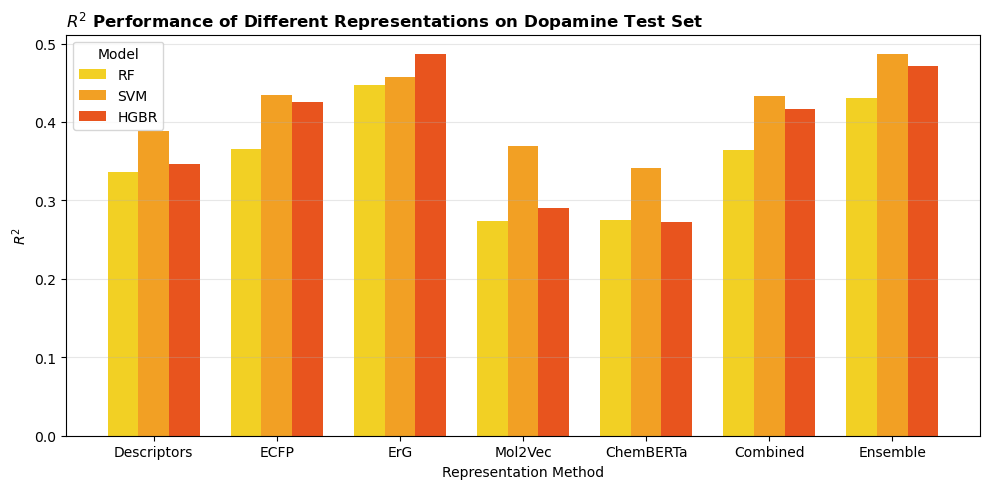

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def plot_r2_comparison(representations, rf_r2, svm_r2, hgbr_r2, title):
    x = np.arange(len(representations))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, rf_r2, width, label='RF', color='#F2D024')
    ax.bar(x, svm_r2, width, label='SVM', color='#F2A024')
    ax.bar(x + width, hgbr_r2, width, label='HGBR', color='#E8541E')

    ax.set_xlabel('Representation Method')
    ax.set_ylabel('$R^2$')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(representations)
    ax.legend(title='Model')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_r2_comparison(
    representations=['Descriptors', 'ECFP', 'ErG', 'Mol2Vec', 'ChemBERTa', 'Combined', 'Ensemble'],
    rf_r2=[0.336, 0.365, 0.447, 0.274, 0.275, 0.364, 0.431],
    svm_r2=[0.388, 0.435, 0.457, 0.369, 0.341, 0.433, 0.487],
    hgbr_r2=[0.347, 0.425, 0.487, 0.290, 0.272, 0.416, 0.471],
    title='$R^2$ Performance of Different Representations on Dopamine Test Set'
)